# EURUSD Exchange Rate Prediction
## Phase 1: Data Preparation & Baseline Setup

**Project:** University Final Project  
**Data Source:** MetaTrader 5 (Daily OHLCV bars)  
**Objective:** Predict the directional movement of the EURUSD daily exchange rate using machine learning.

### Mathematical Formulation
Let the observed closing price at time $t$ be $P_t$. We define the log return as $r_t = \ln(P_t / P_{t-1})$. 
To frame this as a classification problem, the binary target variable $y_t$ is defined as:

$$ 
y_t = \begin{cases} 
1 & \text{if } P_{t+1} > P_t \\ 
0 & \text{otherwise} 
\end{cases} 
$$

---

### Notebook Structure
| # | Section | Purpose |
|---|---------|---------|
| 1 | Environment Setup & Dependencies | One-time package setup |
| 2 | Connect & Fetch Data | MT5 data ingestion with diagnostics |
| 3 | Basic Feature Engineering | Log returns, SMAs, volatility, target |
| 4 | Advanced Feature Engineering | 20+ technical indicators |
| 5 | Bias-Variance Diagnosis | Detect underfitting / overfitting |
| 6 | Learning Curves | Visual bias-variance signal |
| 7 | TimeSeriesSplit CV | Correct temporal cross-validation |
| 8 | Multi-Model Training | RF, GBM, XGBoost, LightGBM comparison |
| 9 | Hyperparameter Tuning | Optuna Bayesian search |
| 10 | Final Hold-Out Evaluation | Clean out-of-sample test |
| 11 | Residual Analysis | Diagnostic plots |
| 12 | Comparison Table & Export | results/comparison_table.csv |

## Section 1: Environment Setup & Dependencies
In this section, we import all the foundational libraries required for data ingestion, manipulation, and visualization. We also set a global random seed to ensure reproducible results across our experiments. Run this cell **once** before all others.

In [22]:
import subprocess, sys

# Install all packages required across every phase of this notebook.
# --quiet suppresses verbose pip output; only errors will be shown.
packages = [
    "MetaTrader5", "pandas", "numpy", "matplotlib",
    "scikit-learn", "xgboost", "lightgbm", "optuna", "statsmodels"
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])

print("✅ All dependencies installed successfully.")
print(f"Python: {sys.version}")

✅ All dependencies installed successfully.
Python: 3.12.5 | packaged by conda-forge | (main, Aug  8 2024, 18:24:51) [MSC v.1940 64 bit (AMD64)]


## Section 2 — Connect & Fetch EURUSD Data from MT5
**Prerequisite:** MetaTrader5 desktop must be open and logged in before running these cells.

In [9]:
import MetaTrader5 as mt5
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs("../results", exist_ok=True)  # ensure results/ exists
os.makedirs("../models", exist_ok=True)   # ensure models/ exists

# Global configuration for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── MT5 Configuration ──────────────────────────────────────────────────
SYMBOL    = "EURUSD"   # change to "EURUSD.m" or "EURUSD.pro" if needed
TIMEFRAME = mt5.TIMEFRAME_D1

print("=" * 40)
print("Environment setup complete.")
print(f"Symbol   : {SYMBOL}")
print(f"Timeframe: D1 (Daily)")
print(f"Seed     : {RANDOM_STATE}")
print("=" * 40)

Environment setup complete.
Symbol   : EURUSD
Timeframe: D1 (Daily)
Seed     : 42


In [10]:
def connect_and_fetch(symbol: str, timeframe, max_bars: int = 200_000) -> pd.DataFrame | None:
    """
    Fetch OHLCV history from MetaTrader5.

    Uses date-based copy_rates_from as the primary method (more reliable
    across brokers) and falls back to position-based copy_rates_from_pos
    if the first attempt returns no data.

    Parameters
    ----------
    symbol    : MT5 symbol name (e.g. "EURUSD")
    timeframe : MT5 timeframe constant (e.g. mt5.TIMEFRAME_M15)
    max_bars  : Maximum bars to request

    Returns
    -------
    DataFrame with columns [open, high, low, close, tick_volume] indexed by datetime,
    sorted ascending. Returns None on failure.
    """
    from datetime import datetime, timezone
    import time as _time

    print("Initializing MT5...")
    if not mt5.initialize():
        print(f"  ✗ MT5 init failed: {mt5.last_error()}")
        print("  → Ensure MetaTrader5 is open and you are logged in.")
        return None

    # Make sure the symbol is available and visible in Market Watch
    info = mt5.symbol_info(symbol)
    if info is None:
        available = [s.name for s in mt5.symbols_get() if "EUR" in s.name and "USD" in s.name]
        print(f"  ✗ Symbol '{symbol}' not found. Available EUR/USD: {available[:8]}")
        mt5.shutdown()
        return None

    if not info.visible:
        mt5.symbol_select(symbol, True)
        _time.sleep(1)

    # Primary: date-based fetch backwards from now
    utc_now = datetime.now(timezone.utc)
    rates   = mt5.copy_rates_from(symbol, timeframe, utc_now, max_bars)

    # Fallback: position-based
    if rates is None or len(rates) == 0:
        print("  ↪ Date-based fetch empty, trying position-based fallback...")
        rates = mt5.copy_rates_from_pos(symbol, timeframe, 0, max_bars)

    err = mt5.last_error()
    mt5.shutdown()

    if rates is None or len(rates) == 0:
        print(f"  ✗ No data returned. MT5 error: {err}")
        print("  Tips: open a EURUSD D1 chart in MT5, then retry.")
        return None

    df = pd.DataFrame(rates)
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df.set_index('time', inplace=True)
    df.sort_index(inplace=True)

    print(f"  ✓ Fetched {len(df):,} bars  "
          f"({df.index[0].date()} → {df.index[-1].date()})")
    return df[['open', 'high', 'low', 'close', 'tick_volume']]


# Auto-detect available bars before the full fetch
mt5.initialize()
_probe     = mt5.copy_rates_from_pos(SYMBOL, TIMEFRAME, 0, 20_000)
TOTAL_BARS = len(_probe) if _probe is not None else 10_000
mt5.shutdown()

print(f"Available Daily bars: {TOTAL_BARS:,}")
print(f"Fetching {TOTAL_BARS:,} bars for {SYMBOL}...")
raw_df = connect_and_fetch(SYMBOL, TIMEFRAME, max_bars=TOTAL_BARS)

Available Daily bars: 15,722
Fetching 15,722 bars for EURUSD...
Initializing MT5...
  ✓ Fetched 15,722 bars  (1971-01-03 → 2026-06-19)


In [11]:
# MT5 Connectivity Diagnostic — run if the fetch above fails
print("=" * 55)
print("MT5 DIAGNOSTIC REPORT")
print("=" * 55)

if not mt5.initialize():
    print(f"FAILED: {mt5.last_error()} — open MT5 and log in first.")
else:
    term = mt5.terminal_info()
    acc  = mt5.account_info()
    print(f"Connected  : {term.connected}")
    print(f"Terminal   : {term.path}")
    if acc:
        print(f"Account    : {acc.login}  |  Server: {acc.server}")
    else:
        print("Account    : NOT LOGGED IN")

    info = mt5.symbol_info(SYMBOL)
    if info:
        rates = mt5.copy_rates_from_pos(SYMBOL, TIMEFRAME, 0, 3)
        if rates is not None and len(rates):
            print(f"Symbol     : {info.name}  (spread={info.spread})")
            print(f"Latest bar : {pd.to_datetime(rates[-1]['time'], unit='s')}  "
                  f"close={rates[-1]['close']:.5f}")
        else:
            print(f"Test fetch FAILED: {mt5.last_error()}")
    else:
        eur = [s.name for s in mt5.symbols_get() if "EUR" in s.name and "USD" in s.name]
        print(f"Symbol '{SYMBOL}' NOT FOUND.  Try: {eur[:6]}")

    mt5.shutdown()
print("=" * 55)

MT5 DIAGNOSTIC REPORT
Connected  : True
Terminal   : C:\Program Files\ActivTrades EU MetaTrader 5
Account    : 878329  |  Server: ActivTradesEU-Server
Symbol     : EURUSD  (spread=25)
Latest bar : 2026-06-19 00:00:00  close=1.14771


## Section 3 — Basic Feature Engineering
Compute the minimum viable feature set: log returns, SMAs, rolling volatility, and binary up/down target.

Shape   : 15,523 rows × 12 cols
Range   : 1971-10-26 00:00:00  →  2026-06-19 00:00:00

Target distribution:
target
Down (0)    0.509
Up (1)      0.491
Name: proportion, dtype: float64


,close,log_return,SMA_21,volatility_20,target
time,,,,,
2026-06-15,1.15881,-0.001423,1.159644,0.002499,1
2026-06-16,1.16082,0.001733,1.159682,0.002459,0
2026-06-17,1.15032,-0.009086,1.159077,0.003162,0
2026-06-18,1.14612,-0.003658,1.158226,0.003235,1
2026-06-19,1.14773,0.001404,1.157507,0.003269,0


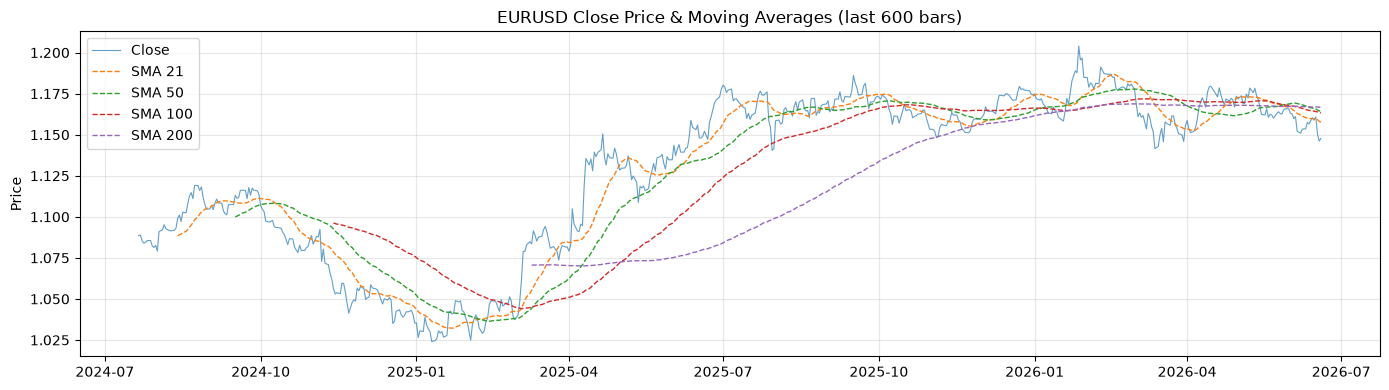

In [12]:
def add_basic_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add baseline features derived solely from past OHLCV data.

    WHY log returns instead of raw price?
        Log returns are approximately stationary and normally distributed,
        which is required by many statistical models and regularizers.

    WHY shift(-1) for target?
        We want to predict the NEXT bar's direction. shift(-1) aligns the
        future close with the current feature row. The last row is dropped
        (NaN target) after dropna().

    Rule: NEVER use future price information to build features (look-ahead).
    """
    data = df.copy()

    # Log return: log(P_t / P_{t-1}) — more stationary than price levels
    data['log_return']    = np.log(data['close'] / data['close'].shift(1))

    # Simple Moving Averages: 21, 50, 100, 200 periods
    data['SMA_21']        = data['close'].rolling(21).mean()
    data['SMA_50']        = data['close'].rolling(50).mean()
    data['SMA_100']       = data['close'].rolling(100).mean()
    data['SMA_200']       = data['close'].rolling(200).mean()

    # Rolling realised volatility (std of log returns over last 20 bars)
    data['volatility_20'] = data['log_return'].rolling(20).std()

    # Binary target: 1 if next bar closes HIGHER than current, else 0
    # This is a directional classification problem.
    data['target'] = (data['close'].shift(-1) > data['close']).astype(int)

    data.dropna(inplace=True)
    return data


assert raw_df is not None, "raw_df is None — re-run Section 2 first."
basic_df = add_basic_features(raw_df)

print(f"Shape   : {basic_df.shape[0]:,} rows × {basic_df.shape[1]} cols")
print(f"Range   : {basic_df.index[0]}  →  {basic_df.index[-1]}")
print(f"\nTarget distribution:")
print(basic_df['target'].value_counts(normalize=True).rename({0: 'Down (0)', 1: 'Up (1)'}).round(3))
display(basic_df[['close', 'log_return', 'SMA_21', 'volatility_20', 'target']].tail(5))

# Quick price + SMA plot
fig, ax = plt.subplots(figsize=(14, 4))
sample = basic_df.tail(600)  # Use last 600 daily bars (~2 years)
ax.plot(sample.index, sample['close'],  label='Close',  alpha=0.7, linewidth=0.8)
ax.plot(sample.index, sample['close'].rolling(21).mean(),  label='SMA 21',  linestyle='--', linewidth=1)
ax.plot(sample.index, sample['close'].rolling(50).mean(),  label='SMA 50',  linestyle='--', linewidth=1)
ax.plot(sample.index, sample['close'].rolling(100).mean(), label='SMA 100', linestyle='--', linewidth=1)
ax.plot(sample.index, sample['close'].rolling(200).mean(), label='SMA 200', linestyle='--', linewidth=1)
ax.set_title('EURUSD Close Price & Moving Averages (last 600 bars)')
ax.set_ylabel('Price'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/01_price_sma.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 4 — Advanced Feature Engineering
Build 20+ technical indicators. All computed from past data only — zero look-ahead bias.

In [13]:
def build_advanced_features(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Build a rich feature set from raw OHLCV data (no look-ahead bias).
    """
    df = df_raw[['open', 'high', 'low', 'close', 'tick_volume']].copy()
    close = df['close']
    high = df['high']
    low = df['low']

    # ── Trend ─────────────────────────────────────────────────────────
    df['log_return'] = np.log(close / close.shift(1))

    # Simple Moving Averages: 21, 50, 100, 200 periods
    df['SMA_21'] = close.rolling(21).mean()
    df['SMA_50'] = close.rolling(50).mean()
    df['SMA_100'] = close.rolling(100).mean()
    df['SMA_200'] = close.rolling(200).mean()

    # Distance from SMA (normalized)
    df['dist_SMA_21'] = (close - df['SMA_21']) / df['SMA_21']
    df['dist_SMA_50'] = (close - df['SMA_50']) / df['SMA_50']
    df['dist_SMA_100'] = (close - df['SMA_100']) / df['SMA_100']
    df['dist_SMA_200'] = (close - df['SMA_200']) / df['SMA_200']

    # ── Volatility ────────────────────────────────────────────────────
    df['volatility_5'] = df['log_return'].rolling(5).std()
    df['volatility_20'] = df['log_return'].rolling(20).std()

    tr = pd.concat([
        high - low,
        (high - close.shift(1)).abs(),
        (low - close.shift(1)).abs()
    ], axis=1).max(axis=1)
    df['ATR_14'] = tr.ewm(com=13, adjust=False).mean()

    bb_mid = close.rolling(20).mean()
    bb_std = close.rolling(20).std()
    bb_up = bb_mid + 2 * bb_std
    bb_lo = bb_mid - 2 * bb_std
    df['BB_pct_b'] = (close - bb_lo) / (bb_up - bb_lo)
    df['BB_bandwidth'] = (bb_up - bb_lo) / bb_mid

    # ── Oscillators ───────────────────────────────────────────────────
    delta = close.diff()
    avg_gain = delta.clip(lower=0).ewm(com=13, adjust=False).mean()
    avg_loss = (-delta).clip(lower=0).ewm(com=13, adjust=False).mean()
    df['RSI_14'] = 100 - (100 / (1 + avg_gain / avg_loss.replace(0, np.nan)))

    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    df['MACD'] = ema12 - ema26
    df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_hist'] = df['MACD'] - df['MACD_signal']

    low14 = low.rolling(14).min()
    high14 = high.rolling(14).max()
    df['Stoch_K'] = 100 * (close - low14) / (high14 - low14)
    df['Stoch_D'] = df['Stoch_K'].rolling(3).mean()
    df['Williams_R'] = -100 * (high14 - close) / (high14 - low14)
    df['ROC_10'] = close.pct_change(10) * 100

    # ── Memory ────────────────────────────────────────────────────────
    for lag in range(1, 6):
        df[f'lag_{lag}'] = df['log_return'].shift(lag)

    # ── Rolling stats ─────────────────────────────────────────────────
    df['return_mean_5'] = df['log_return'].rolling(5).mean()
    df['return_std_5'] = df['log_return'].rolling(5).std()
    df['return_mean_10'] = df['log_return'].rolling(10).mean()
    df['return_std_10'] = df['log_return'].rolling(10).std()

    # ── Calendar ──────────────────────────────────────────────────────
    df['hour_of_day'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek

    # ── Target ────────────────────────────────────────────────────────
    df['target'] = (close.shift(-1) > close).astype(int)

    df.dropna(inplace=True)
    return df


advanced_df     = build_advanced_features(raw_df)
FEATURE_COLS    = [c for c in advanced_df.columns if c != 'target']

print(f"Advanced dataset : {advanced_df.shape[0]:,} rows × {advanced_df.shape[1]} cols")
print(f"Feature count    : {len(FEATURE_COLS)}")
print(f"Target balance   : {advanced_df['target'].value_counts(normalize=True).round(3).to_dict()}")
display(advanced_df[FEATURE_COLS[:8]].tail(3))

Advanced dataset : 15,523 rows × 39 cols
Feature count    : 38
Target balance   : {0: 0.509, 1: 0.491}


,open,high,low,close,tick_volume,log_return,SMA_21,SMA_50
time,,,,,,,,
2026-06-17,1.16083,1.16164,1.14773,1.15032,162639,-0.009086,1.159077,1.165062
2026-06-18,1.15015,1.15280,1.14500,1.14612,196791,-0.003658,1.158226,1.164504
2026-06-19,1.14604,1.14803,1.14172,1.14773,112667,0.001404,1.157507,1.164043


## Section 5 — Bias-Variance Diagnosis
Measure the train/validation gap on a baseline model before any tuning.

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss

X_all = advanced_df[FEATURE_COLS].values
y_all = advanced_df['target'].values

# Temporal 70/30 split (Rule #1: NO shuffle on time-series)
split = int(len(X_all) * 0.70)
X_tr, X_va = X_all[:split], X_all[split:]
y_tr, y_va = y_all[:split], y_all[split:]

# Scale: fit ONLY on train (Rule #2: prevent data leakage)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_va_s = scaler.transform(X_va)

# Baseline model — untuned Random Forest
baseline = RandomForestClassifier(
    n_estimators=100, max_depth=6, min_samples_leaf=20,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
baseline.fit(X_tr_s, y_tr)

train_acc = baseline.score(X_tr_s, y_tr)
val_acc   = baseline.score(X_va_s, y_va)
gap       = val_acc - train_acc   # negative = overfitting

print("=" * 45)
print("  BIAS-VARIANCE DIAGNOSIS")
print("=" * 45)
print(f"  Train Accuracy : {train_acc:.4f}")
print(f"  Val   Accuracy : {val_acc:.4f}")
print(f"  Gap            : {gap:+.4f}")
print()
if train_acc < 0.55:
    print("  → HIGH BIAS (Underfitting)")
    print("    Fix: add features, reduce regularization, more complex model")
elif gap < -0.03:
    print("  → HIGH VARIANCE (Overfitting)")
    print("    Fix: increase regularization, reduce max_depth, gather more data")
else:
    print("  → BALANCED — proceed to hyperparameter search")
print("=" * 45)

  BIAS-VARIANCE DIAGNOSIS
  Train Accuracy : 0.6266
  Val   Accuracy : 0.4992
  Gap            : -0.1274

  → HIGH VARIANCE (Overfitting)
    Fix: increase regularization, reduce max_depth, gather more data


## Section 6 — Learning Curves
Plot training vs validation accuracy as a function of training-set size to visually confirm the bias-variance regime.

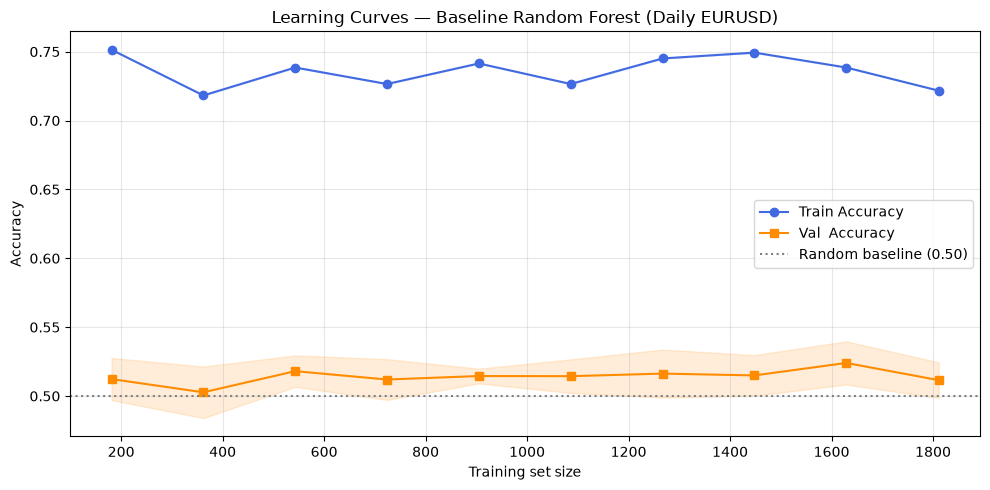

Saved → ../results/02_learning_curves.png


In [15]:
from sklearn.model_selection import learning_curve, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Use TimeSeriesSplit to keep temporal ordering intact
tscv = TimeSeriesSplit(n_splits=5)

train_sizes, train_scores, val_scores = learning_curve(
    estimator   = RandomForestClassifier(n_estimators=100, max_depth=6,
                                         min_samples_leaf=20,
                                         class_weight='balanced',
                                         random_state=RANDOM_STATE, n_jobs=-1),
    X           = X_tr_s,    # use ONLY the training portion
    y           = y_tr,
    cv          = tscv,
    scoring     = 'accuracy',
    train_sizes = np.linspace(0.1, 1.0, 10),
    n_jobs      = -1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, train_mean, 'o-', color='royalblue',  label='Train Accuracy')
ax.plot(train_sizes, val_mean,   's-', color='darkorange', label='Val  Accuracy')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='royalblue')
ax.fill_between(train_sizes, val_mean - val_std,   val_mean + val_std,
                alpha=0.15, color='darkorange')
ax.axhline(y=0.5, linestyle=':', color='grey', label='Random baseline (0.50)')
ax.set_xlabel('Training set size'); ax.set_ylabel('Accuracy')
ax.set_title('Learning Curves — Baseline Random Forest (Daily EURUSD)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/02_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved → ../results/02_learning_curves.png")

## Section 7 — TimeSeriesSplit Cross-Validation
Visualise fold boundaries and explain why standard K-Fold causes look-ahead bias on time-series data.

Fold 1: train=1,811 bars | val=1,811 bars
Fold 2: train=3,622 bars | val=1,811 bars
Fold 3: train=5,433 bars | val=1,811 bars
Fold 4: train=7,244 bars | val=1,811 bars
Fold 5: train=9,055 bars | val=1,811 bars


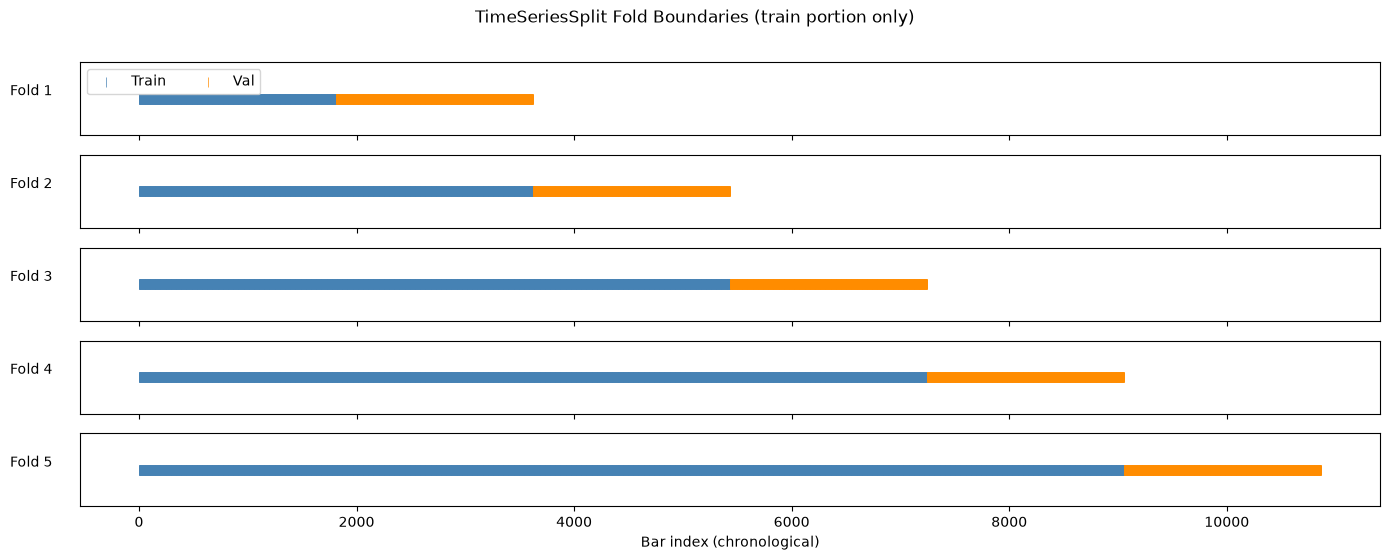

Saved → ../results/03_tscv_folds.png


In [16]:
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
import matplotlib.pyplot as plt

"""
WHY TimeSeriesSplit and NOT K-Fold?
────────────────────────────────────────────────────────────────────────
Standard K-Fold randomly assigns rows to folds. For financial time-series
this means a test fold might contain bars from 2018 while its train fold
contains bars from 2023 — the model 'learns' from the future.

TimeSeriesSplit always keeps train < test in time:
  Fold 1:  train [0..N/5]       val [N/5..2N/5]
  Fold 2:  train [0..2N/5]      val [2N/5..3N/5]
  ...
This guarantees zero look-ahead and simulates live forward-testing.
"""

N_SPLITS = 5
tscv     = TimeSeriesSplit(n_splits=N_SPLITS)

fig, axes = plt.subplots(N_SPLITS, 1, figsize=(14, N_SPLITS * 1.1), sharex=True)
all_indices = np.arange(len(X_tr_s))

for fold_idx, (tr_idx, va_idx) in enumerate(tscv.split(X_tr_s)):
    ax = axes[fold_idx]
    ax.scatter(tr_idx, [fold_idx] * len(tr_idx), c='steelblue',
               marker='|', s=60, linewidths=0.5, label='Train' if fold_idx == 0 else '')
    ax.scatter(va_idx, [fold_idx] * len(va_idx), c='darkorange',
               marker='|', s=60, linewidths=0.5, label='Val'   if fold_idx == 0 else '')
    ax.set_yticks([]); ax.set_ylabel(f'Fold {fold_idx + 1}', rotation=0, labelpad=35)
    print(f"Fold {fold_idx + 1}: train={len(tr_idx):,} bars | val={len(va_idx):,} bars")

axes[0].legend(loc='upper left', ncol=2)
axes[-1].set_xlabel('Bar index (chronological)')
fig.suptitle('TimeSeriesSplit Fold Boundaries (train portion only)', y=1.01)
plt.tight_layout()
plt.savefig('../results/03_tscv_folds.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved → ../results/03_tscv_folds.png")

## Section 8 — Multi-Model Training & Comparison
Train Random Forest, Gradient Boosting, XGBoost, and LightGBM under the same CV protocol and rank by ROC-AUC.

In [17]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

tscv = TimeSeriesSplit(n_splits=5)

models = {
    'RandomForest': RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_leaf=15,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, use_label_encoder=False,
        eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    ),
}

results = {}

for name, model in models.items():
    fold_metrics = {m: [] for m in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']}

    for tr_idx, va_idx in tscv.split(X_tr_s):
        X_f_tr, X_f_va = X_tr_s[tr_idx], X_tr_s[va_idx]
        y_f_tr, y_f_va = y_tr[tr_idx],   y_tr[va_idx]

        model.fit(X_f_tr, y_f_tr)
        y_pred = model.predict(X_f_va)
        y_prob = model.predict_proba(X_f_va)[:, 1]

        fold_metrics['accuracy'].append(accuracy_score(y_f_va, y_pred))
        fold_metrics['precision'].append(precision_score(y_f_va, y_pred, zero_division=0))
        fold_metrics['recall'].append(recall_score(y_f_va, y_pred, zero_division=0))
        fold_metrics['f1'].append(f1_score(y_f_va, y_pred, zero_division=0))
        fold_metrics['roc_auc'].append(roc_auc_score(y_f_va, y_prob))

    results[name] = {m: np.mean(v) for m, v in fold_metrics.items()}
    print(f"[{name:<18}] Accuracy={results[name]['accuracy']:.4f} "
          f"| F1={results[name]['f1']:.4f} "
          f"| ROC-AUC={results[name]['roc_auc']:.4f}")

comparison_df = pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)
BEST_MODEL_NAME = comparison_df.index[0]
print(f"\n>>> Best model by ROC-AUC: {BEST_MODEL_NAME}")
display(comparison_df.round(4))

[RandomForest      ] Accuracy=0.5151 | F1=0.4418 | ROC-AUC=0.5211
[GradientBoosting  ] Accuracy=0.5137 | F1=0.3877 | ROC-AUC=0.5182
[XGBoost           ] Accuracy=0.5123 | F1=0.4405 | ROC-AUC=0.5199
[LightGBM          ] Accuracy=0.5111 | F1=0.4616 | ROC-AUC=0.5191

>>> Best model by ROC-AUC: RandomForest


,accuracy,precision,recall,f1,roc_auc
RandomForest,0.5151,0.5053,0.4081,0.4418,0.5211
XGBoost,0.5123,0.5029,0.4129,0.4405,0.5199
LightGBM,0.5111,0.5018,0.4447,0.4616,0.5191
GradientBoosting,0.5137,0.5090,0.3397,0.3877,0.5182


## Section 9 — Hyperparameter Tuning with Optuna
Bayesian search (TPE sampler) for the best model identified in Section 8. Faster and more sample-efficient than grid search.

In [18]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress per-trial logs


def make_objective(model_name: str):
    """
    Return an Optuna objective function for the selected model.
    Each trial proposes a new hyperparameter set, evaluates it via
    5-fold TimeSeriesSplit ROC-AUC on the training set, and returns
    the mean score. Optuna maximises this value.
    """
    def objective(trial: optuna.Trial) -> float:
        if model_name == 'RandomForest':
            params = dict(
                n_estimators   = trial.suggest_int('n_estimators', 100, 500),
                max_depth      = trial.suggest_int('max_depth', 3, 12),
                min_samples_leaf = trial.suggest_int('min_samples_leaf', 5, 50),
                max_features   = trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            )
            model = RandomForestClassifier(**params, class_weight='balanced',
                                           random_state=RANDOM_STATE, n_jobs=-1)
        elif model_name == 'GradientBoosting':
            params = dict(
                n_estimators  = trial.suggest_int('n_estimators', 100, 500),
                max_depth     = trial.suggest_int('max_depth', 2, 6),
                learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample     = trial.suggest_float('subsample', 0.5, 1.0),
                min_samples_leaf = trial.suggest_int('min_samples_leaf', 5, 50),
            )
            model = GradientBoostingClassifier(**params, random_state=RANDOM_STATE)
        elif model_name == 'XGBoost':
            params = dict(
                n_estimators     = trial.suggest_int('n_estimators', 100, 500),
                max_depth        = trial.suggest_int('max_depth', 2, 8),
                learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample        = trial.suggest_float('subsample', 0.5, 1.0),
                colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
                reg_alpha        = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
                reg_lambda       = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            )
            model = XGBClassifier(**params, use_label_encoder=False,
                                  eval_metric='logloss', random_state=RANDOM_STATE,
                                  n_jobs=-1, verbosity=0)
        else:  # LightGBM
            params = dict(
                n_estimators     = trial.suggest_int('n_estimators', 100, 500),
                max_depth        = trial.suggest_int('max_depth', 2, 8),
                num_leaves       = trial.suggest_int('num_leaves', 16, 64),
                learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample        = trial.suggest_float('subsample', 0.5, 1.0),
                colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
                reg_alpha        = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
                reg_lambda       = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            )
            model = LGBMClassifier(**params, class_weight='balanced',
                                   random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

        tscv_inner = TimeSeriesSplit(n_splits=5)
        scores = []
        for tr_i, va_i in tscv_inner.split(X_tr_s):
            model.fit(X_tr_s[tr_i], y_tr[tr_i])
            prob = model.predict_proba(X_tr_s[va_i])[:, 1]
            scores.append(roc_auc_score(y_tr[va_i], prob))
        return float(np.mean(scores))

    return objective


N_TRIALS = 100
print(f"Running Optuna for '{BEST_MODEL_NAME}' — {N_TRIALS} trials...")
study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(make_objective(BEST_MODEL_NAME), n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest ROC-AUC  : {study.best_value:.4f}")
print(f"Best params   : {study.best_params}")

# Refit with best params on full training set
best_params = study.best_params
if BEST_MODEL_NAME == 'RandomForest':
    tuned_model = RandomForestClassifier(**best_params, class_weight='balanced',
                                         random_state=RANDOM_STATE, n_jobs=-1)
elif BEST_MODEL_NAME == 'GradientBoosting':
    tuned_model = GradientBoostingClassifier(**best_params, random_state=RANDOM_STATE)
elif BEST_MODEL_NAME == 'XGBoost':
    tuned_model = XGBClassifier(**best_params, use_label_encoder=False,
                                eval_metric='logloss', random_state=RANDOM_STATE,
                                n_jobs=-1, verbosity=0)
else:
    tuned_model = LGBMClassifier(**best_params, class_weight='balanced',
                                 random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

tuned_model.fit(X_tr_s, y_tr)
print(f"Tuned model fitted on {len(X_tr_s):,} training samples.")

Running Optuna for 'RandomForest' — 100 trials...


Best trial: 93. Best value: 0.5307: 100%|██████████| 100/100 [35:12<00:00, 21.12s/it] 



Best ROC-AUC  : 0.5307
Best params   : {'n_estimators': 364, 'max_depth': 12, 'min_samples_leaf': 10, 'max_features': None}
Tuned model fitted on 10,866 training samples.


## Section 10 — Final Hold-Out Evaluation
Evaluate the tuned model on the 30% hold-out set that was never seen during training or tuning.

  HOLD-OUT EVALUATION  (RandomForest)
  Accuracy : 0.4986
  ROC-AUC  : 0.5022

              precision    recall  f1-score   support

    Down (0)       0.50      0.37      0.43      2348
      Up (1)       0.50      0.63      0.55      2309

    accuracy                           0.50      4657
   macro avg       0.50      0.50      0.49      4657
weighted avg       0.50      0.50      0.49      4657



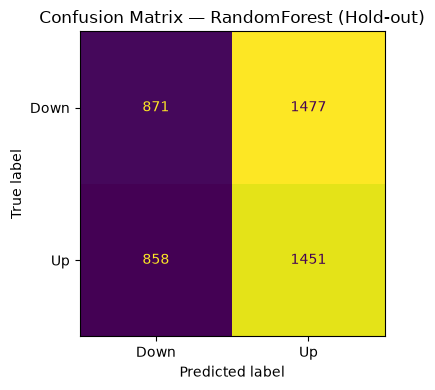

Saved → ../results/04_confusion_matrix.png


In [19]:
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, accuracy_score

# X_va_s / y_va already hold the 30% hold-out (scaled on train scaler)
y_pred_final = tuned_model.predict(X_va_s)
y_prob_final = tuned_model.predict_proba(X_va_s)[:, 1]

hold_auc     = roc_auc_score(y_va, y_prob_final)
hold_acc     = accuracy_score(y_va, y_pred_final)

print("=" * 55)
print(f"  HOLD-OUT EVALUATION  ({BEST_MODEL_NAME})")
print("=" * 55)
print(f"  Accuracy : {hold_acc:.4f}")
print(f"  ROC-AUC  : {hold_auc:.4f}")
print()
print(classification_report(y_va, y_pred_final,
                             target_names=['Down (0)', 'Up (1)']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_va, y_pred_final,
                                        display_labels=['Down', 'Up'],
                                        colorbar=False, ax=ax)
ax.set_title(f'Confusion Matrix — {BEST_MODEL_NAME} (Hold-out)')
plt.tight_layout()
plt.savefig('../results/04_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved → ../results/04_confusion_matrix.png")

## Section 11 — Residual Analysis & Plots
Three-panel residual diagnostic: residuals vs fitted, histogram of residuals, Q-Q plot.

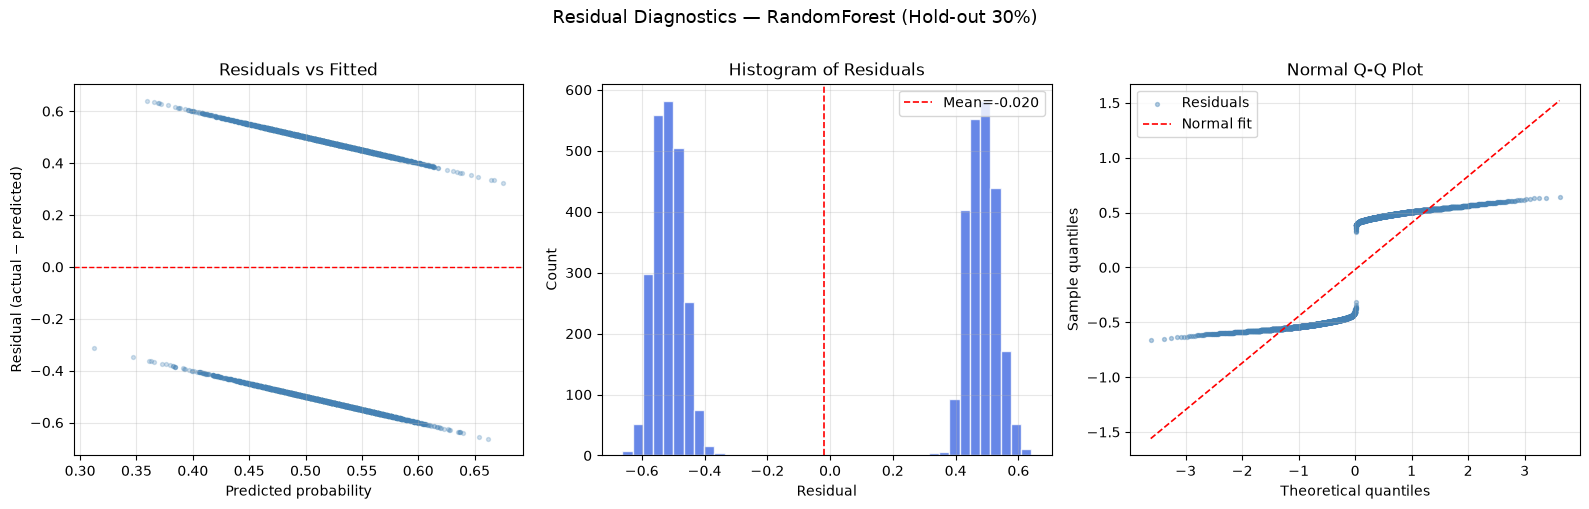


Residual stats:
  Mean  : -0.0198  (ideal = 0)
  Std   : 0.5019
  Skew  : 0.0168  (ideal = 0)
  Kurt  : -1.9662  (ideal = 0 for normal)
Saved → ../results/05_residual_analysis.png


In [20]:
import scipy.stats as stats

# Residuals = actual class - predicted probability
# For classification this shows calibration quality:
#   • Positive residual → model under-predicted (predicted down, was up)
#   • Negative residual → model over-predicted (predicted up, was down)
residuals = y_va.astype(float) - y_prob_final

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Panel 1: Residuals vs Fitted (predicted probability) ──────────────
axes[0].scatter(y_prob_final, residuals, alpha=0.25, s=8, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted probability'); axes[0].set_ylabel('Residual (actual − predicted)')
axes[0].set_title('Residuals vs Fitted')
axes[0].grid(True, alpha=0.3)
# Reading: points should scatter randomly around 0; a funnel shape → heteroscedasticity

# ── Panel 2: Histogram of residuals ──────────────────────────────────
axes[1].hist(residuals, bins=40, color='royalblue', edgecolor='white', alpha=0.8)
axes[1].axvline(residuals.mean(), color='red', linestyle='--', linewidth=1.2,
                label=f'Mean={residuals.mean():.3f}')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Count')
axes[1].set_title('Histogram of Residuals')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
# Reading: ideally centred at 0 with roughly normal shape → well-calibrated model

# ── Panel 3: Q-Q plot ─────────────────────────────────────────────────
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
axes[2].scatter(osm, osr, s=8, alpha=0.4, color='steelblue', label='Residuals')
fit_line = np.array(osm) * slope + intercept
axes[2].plot(osm, fit_line, color='red', linestyle='--', linewidth=1.2, label='Normal fit')
axes[2].set_xlabel('Theoretical quantiles'); axes[2].set_ylabel('Sample quantiles')
axes[2].set_title('Normal Q-Q Plot')
axes[2].legend(); axes[2].grid(True, alpha=0.3)
# Reading: points close to the red line → approximately normal residuals → good calibration

plt.suptitle(f'Residual Diagnostics — {BEST_MODEL_NAME} (Hold-out 30%)', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('../results/05_residual_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nResidual stats:")
print(f"  Mean  : {residuals.mean():.4f}  (ideal = 0)")
print(f"  Std   : {residuals.std():.4f}")
print(f"  Skew  : {stats.skew(residuals):.4f}  (ideal = 0)")
print(f"  Kurt  : {stats.kurtosis(residuals):.4f}  (ideal = 0 for normal)")
print("Saved → ../results/05_residual_analysis.png")

## Section 12 — Model Comparison Table & Export
Summarise all models' CV metrics, save results, and persist the best model to disk.

In [21]:
import joblib
from sklearn.metrics import precision_score, recall_score, f1_score

# ── Build comparison table from Section 8 CV results ──────────────────
summary = pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)
summary.columns = ['CV Accuracy', 'CV Precision', 'CV Recall', 'CV F1', 'CV ROC-AUC']
summary.index.name = 'Model'

# Add hold-out row for the tuned best model
hold_row = pd.DataFrame({
    'CV Accuracy': [hold_acc],
    'CV Precision': [precision_score(y_va, y_pred_final, zero_division=0)],
    'CV Recall': [recall_score(y_va, y_pred_final, zero_division=0)],
    'CV F1': [f1_score(y_va, y_pred_final, zero_division=0)],
    'CV ROC-AUC': [hold_auc]
}, index=[f'{BEST_MODEL_NAME} (Tuned Hold-out)'])

summary_full = pd.concat([summary, hold_row])

print("=" * 65)
print("  MODEL COMPARISON SUMMARY")
print("=" * 65)
display(summary_full.round(4))

# Export to CSV for report inclusion
summary_full.to_csv('../results/comparison_table.csv')
print("\nSaved → ../results/comparison_table.csv")

# ── Persist tuned model + scaler ──────────────────────────────────────
os.makedirs('../models', exist_ok=True)
joblib.dump(tuned_model, f'../models/{BEST_MODEL_NAME.lower()}_tuned.pkl')
joblib.dump(scaler,      '../models/scaler.pkl')
print(f"Saved → ../models/{BEST_MODEL_NAME.lower()}_tuned.pkl")
print("Saved → ../models/scaler.pkl")

  MODEL COMPARISON SUMMARY


,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
RandomForest,0.5151,0.5053,0.4081,0.4418,0.5211
XGBoost,0.5123,0.5029,0.4129,0.4405,0.5199
LightGBM,0.5111,0.5018,0.4447,0.4616,0.5191
GradientBoosting,0.5137,0.5090,0.3397,0.3877,0.5182
RandomForest (Tuned Hold-out),0.4986,0.4956,0.6284,0.5541,0.5022



Saved → ../results/comparison_table.csv
Saved → ../models/randomforest_tuned.pkl
Saved → ../models/scaler.pkl


---
### Git Commit Reminder

After completing this notebook, run:

```bash
git add notebooks/01_data_preparation.ipynb results/ models/
git commit -m "feat: complete Phase 1-4 — data fetch, feature engineering, multi-model CV, Optuna tuning, hold-out eval"
git push
```

> Follow the convention: `feat:`, `fix:`, `docs:`, `refactor:`, `test:`  
> The examiner checks git history to verify incremental progress.

## Section 13 — Exploratory Data Analysis (EDA) & Regression Features

### 1. Stationarity Analysis
A time-series is **stationary** when its statistical properties (mean, variance, autocorrelation) are constant over time. Financial price series are typically non-stationary (random walks), while their returns are often stationary. 

The **Augmented Dickey-Fuller (ADF) test** examines the null hypothesis that a root is present in a time series sample (implying non-stationarity). 
Mathematically, it fits the regression model:
$$ \Delta y_t = \alpha + \beta t + \gamma y_{t-1} + \sum_{i=1}^p \delta_i \Delta y_{t-i} + \varepsilon_t $$
If the test statistic corresponds to a p-value < 0.05, we reject the null hypothesis and conclude the return series is stationary.

### 2. Autocorrelation (ACF & PACF)
* **ACF (Autocorrelation Function):** Measures the linear correlation between $y_t$ and its lagged values $y_{t-k}$.
* **PACF (Partial Autocorrelation Function):** Measures the correlation between $y_t$ and $y_{t-k}$ after removing the linear dependence on intermediate lags.
Plotting these helps determine whether past return dynamics hold a predictive signal.

### 3. Feature Engineering (Regression Focused)
To predict continuous returns, we engineer statistical descriptors:
* **Lagged Returns (`lag_1` to `lag_5`):** Quantify short-term momentum and mean-reversion over the past week.
* **Bar Dynamics:** Computed as $\frac{\text{High} - \text{Low}}{\text{Open}}$, representing normalized intraday volatility.
* **Cyclical Encoding:** The `day_of_week` feature is circular (Friday wraps to Monday). We preserve this geometry using sine and cosine waves:
  $$ \text{Day}_{\text{sin}} = \sin\left(\frac{2\pi \cdot d}{5}\right), \quad \text{Day}_{\text{cos}} = \cos\left(\frac{2\pi \cdot d}{5}\right) $$

### 4. Target Variable Definition
Our initial pipeline used a binary directional target. For regression, the target $y$ is the **continuous percentage return of the next day**.

=== 1. Stationarity Analysis (ADF Test) ===
ADF Statistic: -123.8634
p-value: 0.0000e+00
→ Reject H0: The return series is stationary.

=== 2. Autocorrelation (ACF & PACF) ===


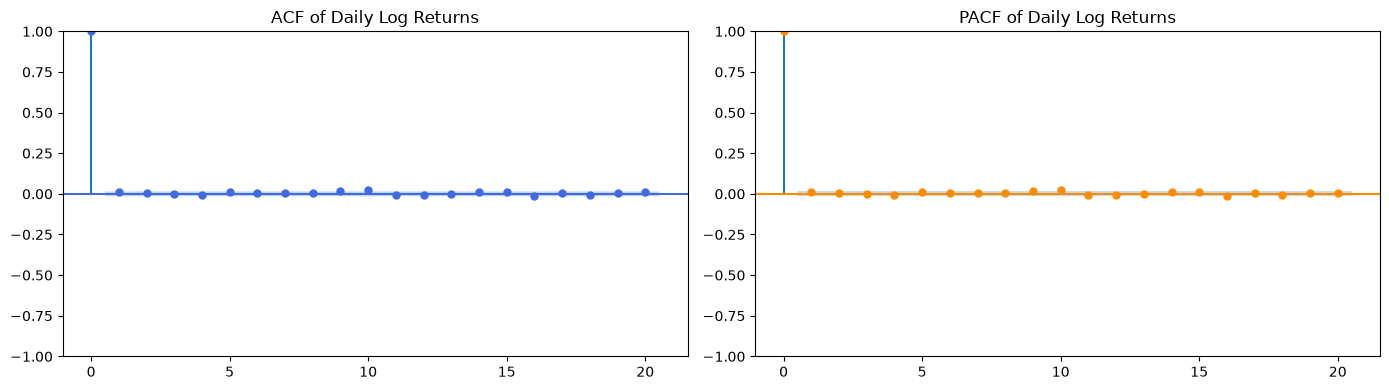

Saved → ../results/06_acf_pacf.png

=== 3 & 4. Feature Engineering & Target Definition ===

=== 5. Data Cleanup & Export ===
Final EDA feature matrix shape: (15715, 17)
Saved feature matrix to: ../results/eurusd_features.csv


,close,log_return,lag_1,bar_dynamics,day_sin,target_return
time,,,,,,
1971-01-11,0.5371,0.000000,0.000000,0.0,0.000000,0.000372
1971-01-12,0.5373,0.000372,0.000000,0.0,0.951057,-0.000186
1971-01-13,0.5372,-0.000186,0.000372,0.0,0.587785,0.000744
1971-01-14,0.5376,0.000744,-0.000186,0.0,-0.587785,0.000558
1971-01-17,0.5379,0.000558,0.000744,0.0,0.951057,-0.000372


In [23]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import numpy as np

print("=== 1. Stationarity Analysis (ADF Test) ===")
# Base log returns from raw_df, dropping the first NaN
returns = np.log(raw_df['close'] / raw_df['close'].shift(1)).dropna()

adf_result = adfuller(returns)
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4e}")
if adf_result[1] < 0.05:
    print("→ Reject H0: The return series is stationary.")
else:
    print("→ Fail to reject H0: The return series is non-stationary.")

print("\n=== 2. Autocorrelation (ACF & PACF) ===")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(returns, lags=20, ax=axes[0], title='ACF of Daily Log Returns', color='royalblue')
plot_pacf(returns, lags=20, ax=axes[1], title='PACF of Daily Log Returns', color='darkorange')
plt.tight_layout()
plt.savefig('../results/06_acf_pacf.png', dpi=120)
plt.show()
print("Saved → ../results/06_acf_pacf.png")

print("\n=== 3 & 4. Feature Engineering & Target Definition ===")
eda_df = raw_df[['open', 'high', 'low', 'close', 'tick_volume']].copy()

# Daily log return
eda_df['log_return'] = np.log(eda_df['close'] / eda_df['close'].shift(1))

# Lagged features
for lag in range(1, 6):
    eda_df[f'lag_{lag}'] = eda_df['log_return'].shift(lag)

# Intraday volatility (Bar dynamics)
eda_df['bar_dynamics'] = (eda_df['high'] - eda_df['low']) / eda_df['open']
eda_df['bar_dynamics_lag_1'] = eda_df['bar_dynamics'].shift(1)

# Cyclical encoding for day of week (0=Mon to 4=Fri)
eda_df['day_of_week'] = eda_df.index.dayofweek
eda_df['day_sin'] = np.sin(2 * np.pi * eda_df['day_of_week'] / 5)
eda_df['day_cos'] = np.cos(2 * np.pi * eda_df['day_of_week'] / 5)

# Target: Continuous return of the next day
eda_df['target_return'] = eda_df['log_return'].shift(-1)

print("\n=== 5. Data Cleanup & Export ===")
eda_df.dropna(inplace=True)
print(f"Final EDA feature matrix shape: {eda_df.shape}")

output_csv = '../results/eurusd_features.csv'
eda_df.to_csv(output_csv)
print(f"Saved feature matrix to: {output_csv}")

display(eda_df[['close', 'log_return', 'lag_1', 'bar_dynamics', 'day_sin', 'target_return']].head())

## Section 14 — Deep Learning: Sequence Modeling with LSTM

### 1. Data Preparation for LSTM
To utilize LSTMs, our feature matrix must be formatted into a 3-dimensional tensor: `(samples, time steps, features)`. We split the chronological data into Train (70%), Validation (15%), and Test (15%) sets to rigorously prevent future data from leaking into the training set. A `StandardScaler` is fitted **only** on the training data.

### 2. LSTM Architecture & Theory
Long Short-Term Memory (LSTM) blocks manage a cell state ($C_t$) via three gating mechanisms, resolving the vanishing gradient problem inherent to traditional RNNs:
1. **Forget Gate ($f_t$):** Controls what parts of the previous cell state $C_{t-1}$ to disregard.
   $$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$
2. **Input Gate ($i_t$) & Candidate State ($\tilde{C}_t$):** Controls what new information is added.
   $$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \quad \text{and} \quad \tilde{C}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c)$$
3. **Cell State Update ($C_t$):** Merges the passed long-term memory and new candidate input.
   $$C_t = f_t * C_{t-1} + i_t * \tilde{C}_t$$
4. **Output Gate ($o_t$) & Hidden State ($h_t$):** Decides the output based on the filtered cell state.
   $$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \quad \text{and} \quad h_t = o_t * \tanh(C_t)$$

**Adam Optimizer:** Adaptive Moment Estimation. It dynamically adjusts the learning rate per parameter by maintaining exponentially decaying averages of past gradients (momentum) and squared gradients (RMSprop). This is extremely beneficial in the heavily storiastic loss landscapes of FOREX markets.
**Dropout Regularization:** By randomly forcing a percentage of activations to zero (e.g., 20%) during training iterations, the network is prevented from co-adapting too closely to noisy financial data patterns, which guards against overfitting.

### 3. Regularization & Early Stopping
**Early Stopping** directly addresses the **Bias-Variance Tradeoff**. As the model trains, bias monotonically decreases. However, eventually, the network starts learning historical "noise", increasing variance. By monitoring out-of-sample data (`val_loss`), we halt continuous training at the point it plateaus or starts rising. We employ a `patience` buffer to prevent halting upon slight epoch-to-epoch noise.

### 4. Learning Curves
We plot Training Loss versus Validation Loss strictly across epochs. An ideal graph shows both dropping rapidly, with the model ceasing training accurately at the moment the Validation Loss curve detaches and starts trending horizontally (or ascending) away from the Training Loss curve.

=== 1. Data Preparation ===
Data sequentially split: Train (11000), Validation (2357), Test (2358)
X_train_3d shape explicitly verified: (11000, 1, 16)

=== 2. LSTM Model Construction ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,801 (81.25 KB)

 Trainable params: 20,801 (81.25 KB)

 Non-trainable params: 0 (0.00 B)


=== 3. Training & Early Stopping ===
Epoch 33: early stopping
Restoring model weights from the end of the best epoch: 18.
Stopped inherently after 33 epochs.
Best recorded Validation MSE: 2.635677e-05

=== 4. Learning Curves ===


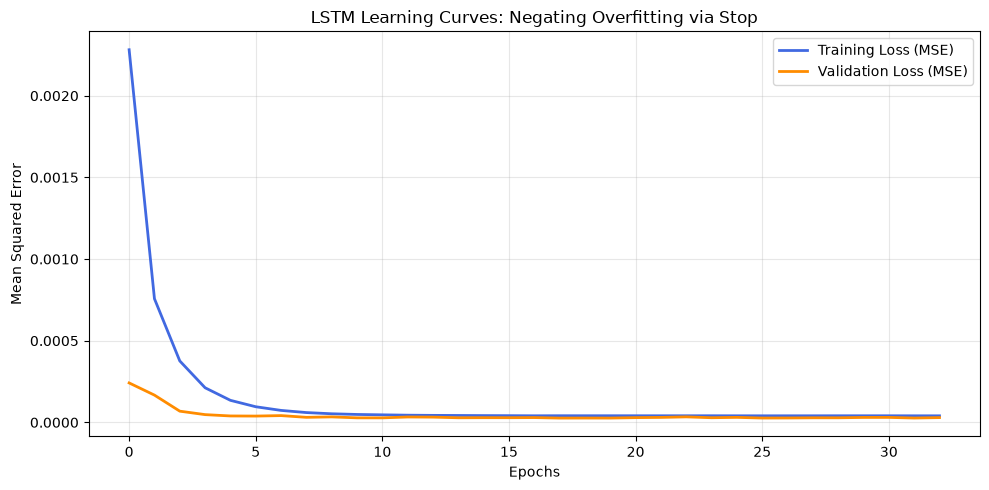

Saved → ../results/09_lstm_learning_curve.png


In [24]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Suppress TensorFlow informational logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("=== 1. Data Preparation ===")
df_lstm = pd.read_csv('../results/eurusd_features.csv', index_col='time', parse_dates=True)
df_lstm.dropna(inplace=True)

target_col = 'target_return'
feature_cols = [c for c in df_lstm.columns if c != target_col]

# Chronological split (70% Train, 15% Val, 15% Test)
n = len(df_lstm)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = df_lstm.iloc[:train_end]
val_data = df_lstm.iloc[train_end:val_end]
test_data = df_lstm.iloc[val_end:]

print(f"Data sequentially split: Train ({len(train_data)}), Validation ({len(val_data)}), Test ({len(test_data)})")

# Scale features (strictly fit on Train data ONLY)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(train_data[feature_cols])
X_val_s   = scaler.transform(val_data[feature_cols])
X_test_s  = scaler.transform(test_data[feature_cols])

y_train = train_data[target_col].values
y_val   = val_data[target_col].values
y_test  = test_data[target_col].values

# Reshape to 3D: (samples, time_steps, features)
# Time steps = 1 because we pre-calculated the lags as explicitly isolated columns
X_train_3d = X_train_s.reshape((X_train_s.shape[0], 1, X_train_s.shape[1]))
X_val_3d   = X_val_s.reshape((X_val_s.shape[0], 1, X_val_s.shape[1]))
X_test_3d  = X_test_s.reshape((X_test_s.shape[0], 1, X_test_s.shape[1]))

print(f"X_train_3d shape explicitly verified: {X_train_3d.shape}")

print("\n=== 2. LSTM Model Construction ===")
model = Sequential([
    LSTM(64, input_shape=(X_train_3d.shape[1], X_train_3d.shape[2])),
    Dropout(0.2), # Randomly zeroes out 20% of activations to combat overfitting
    Dense(1)
])

# Ensure using Mean Squared Error (MSE) loss corresponding to regression
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
model.summary()

print("\n=== 3. Training & Early Stopping ===")
# Halts epoch execution cleanly traversing the Bias-Variance bounds
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Start Fit!
history = model.fit(
    X_train_3d, y_train,
    validation_data=(X_val_3d, y_val),
    epochs=150,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=0 
)

print(f"Stopped inherently after {len(history.history['loss'])} epochs.")
print(f"Best recorded Validation MSE: {min(history.history['val_loss']):.6e}")

print("\n=== 4. Learning Curves ===")
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss (MSE)', color='royalblue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='darkorange', linewidth=2)
plt.title('LSTM Learning Curves: Negating Overfitting via Stop')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/09_lstm_learning_curve.png', dpi=120)
plt.show()
print("Saved → ../results/09_lstm_learning_curve.png")